In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split
import keras as k
import tensorflow as tf
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\species.zip")
df.head()


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [3]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [4]:
df["Species"].unique(), df["Species"].value_counts()

(array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object),
 Species
 Iris-setosa        50
 Iris-versicolor    50
 Iris-virginica     50
 Name: count, dtype: int64)

In [5]:
y = df["Species"]
x = df[[ 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]

In [8]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y =pd.DataFrame(le.fit_transform(y))

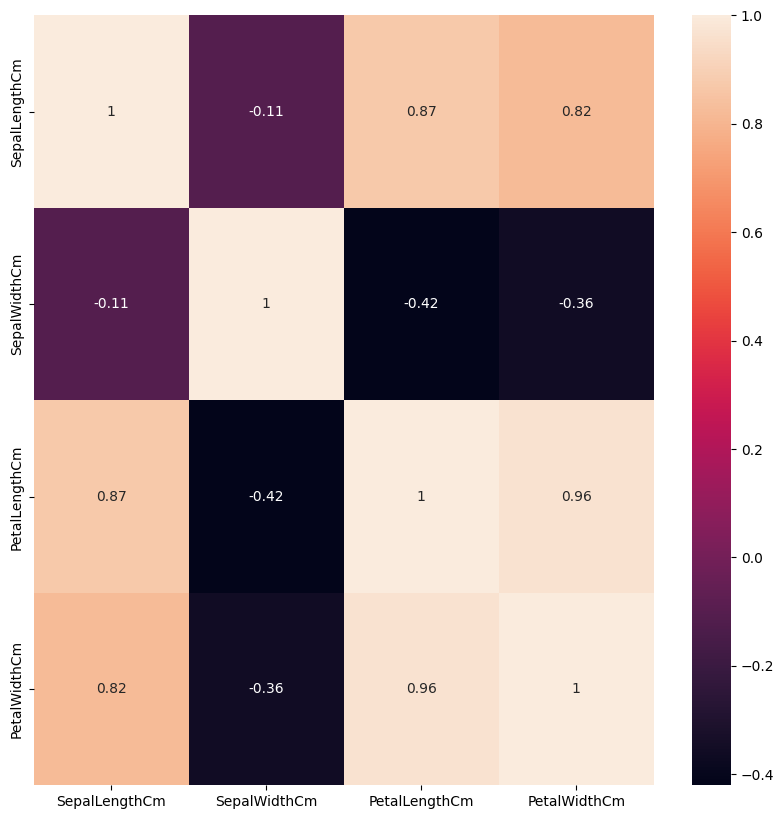

In [10]:
plt.figure(figsize = (10, 10))
sns.heatmap(x.corr(), annot = True)
plt.show()

In [11]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [12]:
df.drop(columns = "Id", axis = 1, inplace = True)

In [13]:

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.20, random_state=42)


In [14]:
df.shape

(150, 5)

In [15]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.fit_transform(x_test)

In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
model = Sequential([
    Dense(24, activation = "relu", input_shape=(x_train.shape[1], )),
     Dense(12, activation = "relu"  ),
    Dense(6, activation = "relu"  ),
     Dense(3, activation = "softmax" ),
])

C:\Users\agraw\Downloads\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 24)                  │             120 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 12)                  │             300 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 6)                   │              78 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 3)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 519 (2.03 KB)

 Trainable params: 519 (2.03 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer = "adam",
    loss = 'sparse_categorical_crossentropy', 
    metrics = ["accuracy"]
)

In [27]:
history = model.fit(x_train, y_train, epochs = 50, batch_size = 32, validation_split = 0.2)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - accuracy: 0.8438 - loss: 0.8087 - val_accuracy: 0.7500 - val_loss: 0.8597
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8333 - loss: 0.7830 - val_accuracy: 0.7917 - val_loss: 0.8377
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.8229 - loss: 0.7559 - val_accuracy: 0.7917 - val_loss: 0.8145
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8125 - loss: 0.7279 - val_accuracy: 0.7917 - val_loss: 0.7910
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.8125 - loss: 0.7014 - val_accuracy: 0.7917 - val_loss: 0.7684
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.8125 - loss: 0.6751 - val_accuracy: 0.7917 - val_loss: 0.7466
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step - accuracy: 0.8125 - loss: 0.6514 - val_accuracy: 0.7500 - val_loss: 0.7252
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 0.8125 - loss: 0.6281 - val_accuracy: 0.7500 - val_loss: 0.7042

In [28]:
loss, accuracy = model.evaluate(x_test, y_test)
print(loss, accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9667 - loss: 0.2196
0.2195674628019333 0.9666666388511658


In [36]:
prediction = model.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step


In [37]:
y_test

np.int64(0)

In [38]:
prediction_class = (prediction > 0.5)

In [41]:
y_test = prediction.argmax( axis=1)

prediction = model.predict(x_test)
prediction_class = np.argmax(prediction, axis=1)

from sklearn.metrics import classification_report

print(classification_report(y_test, prediction_class))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00        10
           2       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [42]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, prediction_class)
cm

array([[10,  0,  0],
       [ 0, 10,  0],
       [ 0,  0, 10]])

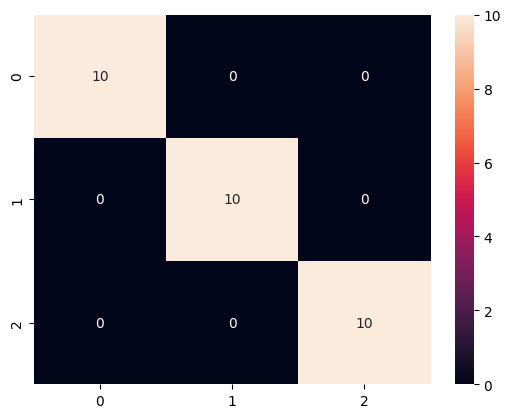

In [43]:
sns.heatmap(cm, annot = True)
plt.show()

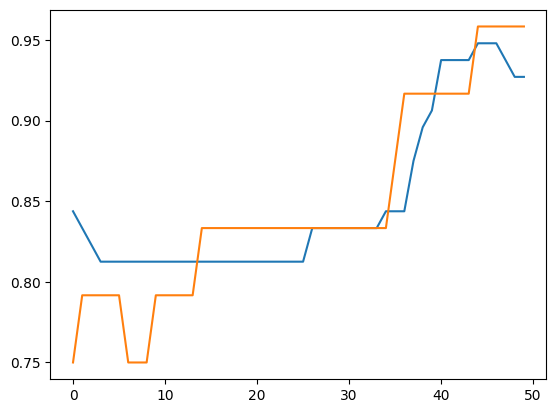

In [44]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.show()